In [1]:
import matplotlib.pyplot as plt
from functools import reduce
from functools import partial
import sys
import os
# from google.colab import drive
# drive.mount('/content/drive')
import h5py
import numpy as np
from timeit import default_timer
import operator
from datetime import date
# !pip install pydmd
# from pydmd import OptDMD, DMD
from scipy.linalg import norm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from pathlib import Path

This file contains scripts that effectively recreate the existing plots in the arXiv paper.

Ok, this shows what files there are... Should be 3 per speed for each model

In [2]:
speed = "5Hz_200fps"

UNet_dir = Path("./UNet Output")
UNet_files = list(UNet_dir.glob(f"*UNet*{speed}*FINAL*.h5"))

# FNO_dir = Path("./FNO Output")
# FNO_files = list(FNO_dir.glob(f"*FNO*{speed}*FINAL*.h5"))

# CNN_dir = Path("./CNN Output")
# CNN_files = list(CNN_dir.glob(f"*CNN*{speed}*FINAL*.h5"))

# DMD_dir = Path("./DMD Output")
# DMD_files = list(DMD_dir.glob(f"*DMD*{speed}*FINAL*.h5"))

print('UNet Files')
print("=" * 50)
for i, h5_file in enumerate(sorted(UNet_files)):
    print(f"# {i}: {h5_file.name}")
print("=" * 50)

UNet Files
# 0: 20260605_UNet_200_epoch_32_5Hz_200fpsFINAL_2.h5
# 1: 20260616_UNet_200_epoch_32_5Hz_200fpsFINAL_2.h5


Ok, here's some functions to make loading data easier

In [3]:
def load_data(model_type, speed):
    data_dir = Path(f"./{model_type} Output")
    data_files = list(data_dir.glob(f"*{model_type}*{speed}*FINAL*.h5"))

    assert len(data_files) >= 1, f"{len(data_files)} files found. Expected >= 1."

    u_actual = []
    u_pred = []
    u_x_mean = []
    u_x_std = []
    u_y_mean = []
    u_y_std = []

    for i, fn in enumerate(sorted(data_files)):
        print(f"# Loading file {i}: {fn.name}")
        with h5py.File(fn, "r") as f:
            temp_actual = f["u_actual"][:]
            temp_pred = f["u_pred"][:]
            u_x_mean = f["u_x_mean"][()]
            u_x_std = f["u_x_std"][()]
            u_y_mean = f["u_y_mean"][()]
            u_y_std = f["u_y_std"][()]

        assert temp_actual.shape[0] == 2, "u_actual shape incorrect"
        assert temp_pred.shape[0] == 2, "u_pred shape incorrect"

        # Un-normalize
        temp_actual[0, ...] = temp_actual[0, ...] * u_x_std + u_x_mean
        temp_actual[1, ...] = temp_actual[1, ...] * u_y_std + u_y_mean
        temp_pred[0, ...] = temp_pred[0, ...] * u_x_std + u_x_mean
        temp_pred[1, ...] = temp_pred[1, ...] * u_y_std + u_y_mean

        u_actual.append(temp_actual)
        u_pred.append(temp_pred)

    return u_actual, u_pred

def load_all_data(model_type, speed):
    u_act, u_pred = load_data(model_type, speed)
    u_act = np.concatenate(u_act, axis=1)
    u_pred = np.concatenate(u_pred, axis=1)
    assert u_act.shape[0] == 2
    assert u_pred.shape[0] == 2
    return u_act, u_pred

def get_u_diff_norm(u_act, u_pred, num_steps=10):
    u_diff = []
    for i in range(num_steps):
        u_diff.append(np.linalg.norm(u_act[..., i+1] - u_pred[..., i+1]) / np.linalg.norm(u_act[..., i+1]))
    return u_diff

Ok, let's load in some data to make some sample plots

In [4]:
model_type, speed = "UNet", "5Hz_200fps"
unet_act, unet_pred = load_all_data(model_type, speed)

# SKIP: only UNet trained
# model_type = "FNO"
# fno_act, fno_pred = load_all_data(model_type, speed)
# model_type = "CNN"
# cnn_act, cnn_pred = load_all_data(model_type, speed)
# model_type = "DMD"
# dmd_act, dmd_pred = load_all_data(model_type, speed)

# Loading file 0: 20260605_UNet_200_epoch_32_5Hz_200fpsFINAL_2.h5
# Loading file 1: 20260616_UNet_200_epoch_32_5Hz_200fpsFINAL_2.h5


Let's start with plotting flow-fields themselves

Ok, the below plot can be used to recreate figure 5 in the paper

(2, 509, 100, 89, 11)
0.13819791


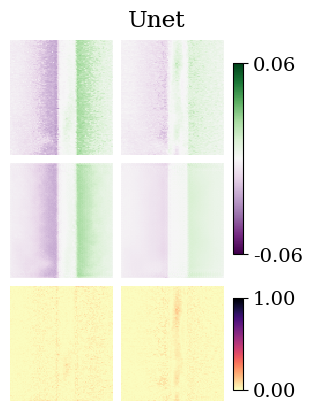

In [5]:
def plot_flow(ffield, cmap="PRGn", vmin=None, vmax=None):
    if vmin is None:
        vmin = np.round(np.min(ffield), decimals=2) - 0.01
    if vmax is None:
        vmax = np.round(np.max(ffield), decimals=2) + 0.01
    im = plt.imshow(ffield, aspect="equal", interpolation="none", cmap=cmap, vmin=vmin, vmax=vmax)
    ax = plt.gca()
    ax.set_aspect("equal")
    ax.set_axis_off()
    return im

def flowvis_comparison(act, act_u, pred, title):
    U = np.mean(act_u[:5, :40, :])
    print(U)

    vmin = -.06
    vmax = .06

    fig, axs = plt.subplots(3, 2, figsize=(4, 4), layout="compressed")

    plt.subplot(3,2,1)
    im = plot_flow(act[:, :, 1], vmin=vmin, vmax=vmax)
    plt.subplot(3,2,2)
    plot_flow(act[:, :, 10], vmin=vmin, vmax=vmax)
    plt.subplot(3,2,3)
    plot_flow(pred[:, :, 1], vmin=vmin, vmax=vmax)
    plt.subplot(3,2,4)
    plot_flow(pred[:, :, 10], vmin=vmin, vmax=vmax)
    cbar = fig.colorbar(im, ax=axs[:2], shrink=0.8)
    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels([f"{vmin:.2f}", f"{vmax:.2f}"])

    plt.subplot(3,2,5)
    im2 = plot_flow(np.abs(act[:, :, 1] - pred[:, :, 1]) / U, vmin=0, vmax=1, cmap="magma_r")
    plt.subplot(3,2,6)
    plot_flow(np.abs(act[:, :, 10] - pred[:, :, 10]) / U, vmin=0, vmax=1, cmap="magma_r")
    cbar2 = fig.colorbar(im2, ax=axs[-1], aspect=10, shrink=0.8)
    cbar2.set_ticks([0, 1])
    cbar2.set_ticklabels(["0.00", "1.00"])

    plt.suptitle(title)
    plt.show()
    plt.close()

# UNet only
print(unet_act.shape)
act = unet_act[1, 0, ...]
pred = unet_pred[1, 0, ...]

plt.rcParams['font.size'] = 14
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
flowvis_comparison(act, unet_act[0, 0, ...], pred, 'Unet')

# SKIP: FNO/CNN/DMD not trained
# act = fno_act[1, 0, ...]; pred = fno_pred[1, 0, ...]
# flowvis_comparison(act, unet_act[0, 0, ...], pred, 'fno')
# act = dmd_act[1, 0, ...]; pred = dmd_pred[1, 0, ...]
# flowvis_comparison(act, unet_act[0, 0, ...], pred, 'dmd')
# act = cnn_act[1, 0, ...]; pred = cnn_pred[1, 0, ...]
# flowvis_comparison(act, unet_act[0, 0, ...], pred, 'cnn')

In [6]:
# SKIP: requires *_longer.h5 file not generated
# def load_longer_data(model_type, speed="5Hz_200fps"):
#     u_actual = []
#     u_pred = []
#     with h5py.File(f'/content/drive/MyDrive/FNO/{model_type}_{speed}_longer.h5', 'r') as f:
#         u_actual.append(f["u_actual_1"][:])
#         u_pred.append(f["u_pred_1"][:])
#         u_actual.append(f["u_actual_2"][:])
#         u_pred.append(f["u_pred_2"][:])
#         u_actual.append(f["u_actual_3"][:])
#         u_pred.append(f["u_pred_3"][:])
# 
#     return np.stack(u_actual), np.stack(u_pred)
# 
# 
# unet_act, unet_pred = load_longer_data("UNet", "5Hz_200fps")
# fno_act, fno_pred = load_longer_data("FNO", "5Hz_200fps")
# cnn_act, cnn_pred = load_longer_data("CNN", "5Hz_200fps")
# dmd_act, dmd_pred = load_longer_data("DMD", "5Hz_200fps")

In [7]:
# SKIP: requires *_longer.h5 file not generated
# def flowvis_comparison(act, act_u,pred,title):
# 
#     U = np.mean(act_u[:5, :40, :])
#     print(U)
# 
#     # plt.figure(figsize=(8, 8))
# 
#     vmin = -.06#np.min((np.round(np.min(act), decimals=2) - 0.01, np.round(np.min(pred), decimals=2) - 0.01))# -0.25
#     vmax = .06#np.max((np.round(np.max(act), decimals=2) + 0.01, np.round(np.max(pred), decimals=2) + 0.01))#0.55
# 
#     fig, axs = plt.subplots(3, 2, figsize=(4, 4), layout="compressed")
# 
# 
#     plt.subplot(3,2,1)
#     im = plot_flow(act[:, :, 1], vmin=vmin, vmax=vmax)
# 
#     plt.subplot(3,2,2)
#     plot_flow(act[:, :, 10], vmin=vmin, vmax=vmax)
#     plt.subplot(3,2,3)
#     plot_flow(pred[:, :, 1], vmin=vmin, vmax=vmax)
#     plt.subplot(3,2,4)
#     plot_flow(pred[:, :, 10], vmin=vmin, vmax=vmax)
#     cbar = fig.colorbar(im, ax=axs[:2], shrink=0.8)
#     cbar.set_ticks([vmin, vmax])
#     cbar.set_ticklabels([f"{vmin:.2f}", f"{vmax:.2f}"])
# 
#     plt.subplot(3,2,5)
#     im2 = plot_flow(np.abs(act[:, :, 1] - pred[:, :, 1]) / U, vmin=0, vmax=1, cmap="BuPu")
#     plt.subplot(3,2,6)
#     plot_flow(np.abs(act[:, :, 10] - pred[:, :, 10]) / U, vmin=0, vmax=1, cmap="BuPu")
#     cbar2 = fig.colorbar(im2, ax=axs[-1], aspect=10, shrink=0.8)
#     cbar2.set_ticks([0, 1])
#     cbar2.set_ticklabels(["0.00", "1.00"])
#     # cbar2.set_label(r'\frac{|u_i^* - u_i|}{U}', labelpad=10, rotation=0)
#     # plt.tight_layout()
# 
#     plt.suptitle(title)
#     plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig3_"+title+".svg"))
#     plt.show()
#     plt.close()
# 
# 
# print(dmd_act.shape)
# # U net
# # This should give me an 89 x 133 x 11 array
# act = unet_act[0,1,0,:,:,:]
# pred = unet_pred[0,1,0,:,:,:]
# flowvis_comparison(act, unet_act[0,0,0,:,:,:],pred,'Unet')
# 
# # FNO net
# # This should give me an 89 x 133 x 11 array
# act = fno_act[0,1,0,:,:,:]
# pred = fno_pred[0,1,0,:,:,:]
# flowvis_comparison(act, fno_act[0,0,0,:,:,:],pred,'FNO')
# 
# # cnn
# # This should give me an 89 x 133 x 11 array
# act = cnn_act[0,1,0,:,:,:]
# pred = cnn_pred[0,1,0,:,:,:]
# flowvis_comparison(act, cnn_act[0,0,0,:,:,:],pred,'CNN')
# 
# # dmd
# # This should give me an 89 x 133 x 11 array
# act = dmd_act[0,1,:,:,:,0]
# pred = dmd_pred[0,1,:,:,:,0]
# flowvis_comparison(act, dmd_act[0,0,:,:,:,0],pred,'DMD')
# 

Ok, let's work on getting plots for themean absolute error (i.e. Figure 6)

In [8]:
# SKIP: requires FNO/CNN/DMD not trained
# # u_act = unet_actual[0]
# # u_pred = unet_pred[0]
# 
# plt.rcParams['font.size'] = 14  # Set default font size to 14
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
# # plt.rcParams['text.usetex'] = True
# 
# # print(np.shape(u_act))
# # print(type(u_act))
# 
# 
# def plot_flow(ffield, cmap="turbo", vmin=None, vmax=None):
#     if vmin is None:
#         vmin = np.round(np.min(ffield), decimals=2) - 0.01
#     if vmax is None:
#         vmax = np.round(np.max(ffield), decimals=2) + 0.01
#     im = plt.imshow(ffield, aspect="equal", interpolation="none", cmap=cmap, vmin=vmin, vmax=vmax)
#     ax = plt.gca()
#     ax.set_aspect("equal")
#     ax.set_axis_off()
#     # plt.tight_layout()
#     return im
# 
# def mean_error_plots(act, pred, labels=[], suptitle=""):
#     fig, axs = plt.subplots(2, 4, figsize=(8, 8), layout="compressed")
# 
#     # Get maximum error for normalizing
#     vmin, vmax = 0, 0.15
#     for i in range(len(act)):
#       print(i)
#       cur_act = act[i]
#       difference = pred[i]-act[i]
#       U = np.mean(cur_act[:,:,:5,:40,-1],axis=(1,2,3))[0]
#       err = np.mean(difference,axis=1)/U
#       vmax = np.max([np.max((np.round(np.max(err), decimals=2) + 0.01, np.round(np.max(err), decimals=2) + 0.01)),vmax])
# 
#     # Generate plots
#     for i in range(len(act)):
#       cur_act = act[i]
#       difference = np.abs(pred[i]-act[i])
#       U = np.mean(cur_act[:,:,:5,:40,-1],axis=(1,2,3))[0]
#       print(difference.shape)
#       print(cur_act.shape)
#       err = np.mean(difference,axis=(1,4))/U
#       plt.subplot(2,4,i+1)
#       im = plot_flow(err[0,:, :], vmin=vmin, vmax=vmax, cmap="magma_r")
#       if labels:
#         plt.title(labels[i])
#       plt.subplot(2,4,i+5)
#       plot_flow(err[1,:, :], vmin=vmin, vmax=vmax, cmap="magma_r")
# 
#     if suptitle:
#       fig.suptitle(suptitle)
#     # Create colorbar
#     cbar = fig.colorbar(im, ax=axs[:2, :], shrink=0.8)
#     # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig8_comparison.svg"))
#     # plt.show()
# 
# mean_error_plots([unet_act, fno_act, cnn_act, dmd_act],
#                  [unet_pred, fno_pred, cnn_pred, dmd_pred],
#                  ["UNet", "FNO", "CNN", "DMD"],
#                  suptitle=f"{speed}")

Ok now I want to plot error as a function of timestep

In [9]:
# SKIP: requires FNO/CNN/DMD not trained
# unet_diff = get_u_diff_norm(unet_act, unet_pred)
# fno_diff = get_u_diff_norm(fno_act, fno_pred)
# cnn_diff = get_u_diff_norm(cnn_act, cnn_pred)
# dmd_diff = get_u_diff_norm(dmd_act, dmd_pred)

In [10]:
# SKIP: requires FNO/CNN/DMD not trained
# 
# # plt.plot(unet_diff,color='#0372B2',marker="o")
# # plt.plot(fno_diff,color='#CC79A6',marker="s")
# # plt.plot(cnn_diff,color='#009F73',marker="D")
# # plt.plot(dmd_diff,color='#D55D03',marker="v")
# plt.plot(unet_diff,color=(148/255,203/255,236/255),marker="o")
# plt.plot(fno_diff,color=(93/255,168/255,153/255),marker="s")
# plt.plot(cnn_diff,color=(194/255,106/255,119/255),marker="D")
# plt.plot(dmd_diff,color=(220/255,205/255,125/255),marker="v")
# plt.legend(["UNet", "FNO", "CNN", "DMD"])
# plt.title(f"{speed}")
# plt.grid(True)
# plt.xlabel("timestep")
# plt.ylabel("normalized error")
# # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig5_10timesteps.svg"))

Ok, now we can look at a single model across Reynolds numbers

In [11]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# def get_u_diff_norm_all(u_act, u_pred, num_steps=10):
#     """
#       Get the normalized difference between the prediction and actual data.
#     """
#     u_diff = []
#     for i in range(num_steps):
#         u_diff.append(np.linalg.norm(u_act[..., i+1] - u_pred[..., i+1]) / np.linalg.norm(u_act[..., i+1]))
# 
#     return u_diff

In [12]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# unet_diff = []
# 
# model_type, speed = "UNet", "2Hz_80fps"
# unet_act_2, unet_pred_2 = load_all_data(model_type, speed)
# unet_diff.append(get_u_diff_norm_all(unet_act_2, unet_pred_2))
# del unet_act_2, unet_pred_2
# 
# speed = "5Hz_200fps"
# unet_act_5, unet_pred_5 = load_all_data(model_type, speed)
# unet_diff.append(get_u_diff_norm_all(unet_act_5, unet_pred_5))
# del unet_act_5, unet_pred_5
# 
# speed = "7Hz_280fps"
# unet_act_7, unet_pred_7 = load_all_data(model_type, speed)
# unet_diff.append(get_u_diff_norm_all(unet_act_7, unet_pred_7))
# del unet_act_7, unet_pred_7
# 
# speed = "10Hz_400fps"
# unet_act_10, unet_pred_10 = load_all_data(model_type, speed)
# unet_diff.append(get_u_diff_norm_all(unet_act_10, unet_pred_10))
# del unet_act_10, unet_pred_10
# 
# speed = "15Hz_600fps"
# unet_act_15, unet_pred_15 = load_all_data(model_type, speed)
# unet_diff.append(get_u_diff_norm_all(unet_act_15, unet_pred_15))
# del unet_act_15, unet_pred_15
# 
# speed = "20Hz_800fps"
# unet_act_20, unet_pred_20 = load_all_data(model_type, speed)
# unet_diff.append(get_u_diff_norm_all(unet_act_20, unet_pred_20))
# del unet_act_20, unet_pred_20
# 
# speed = "25Hz_1000fps"
# unet_act_25, unet_pred_25 = load_all_data(model_type, speed)
# unet_diff.append(get_u_diff_norm_all(unet_act_25, unet_pred_25))
# del unet_act_25, unet_pred_25

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# unet_diff = []

# unet_diff.append(get_u_diff_norm_all(unet_act_2, unet_pred_2))
# print("2Hz done")
# unet_diff.append(get_u_diff_norm_all(unet_act_5, unet_pred_5))
# unet_diff.append(get_u_diff_norm_all(unet_act_7, unet_pred_7))
# unet_diff.append(get_u_diff_norm_all(unet_act_10, unet_pred_10))
# unet_diff.append(get_u_diff_norm_all(unet_act_15, unet_pred_15))
# unet_diff.append(get_u_diff_norm_all(unet_act_20, unet_pred_20))
# unet_diff.append(get_u_diff_norm_all(unet_act_25, unet_pred_25))

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# unet_diff = np.stack(unet_diff)

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# unet_diff.shape

Plotting it. Figure 4b equivalent

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# Re = [240, 650, 900, 1300, 1900, 2500, 3100]
# colorDict = {'UNet': '#0372B2','FNO':'#CC79A6','CNN':'#009F73','DMD':'#D55D03'}
# 
# cmap=plt.colormaps['twilight_shifted']
# 
# for i in range(len(unet_diff[0, :])):
#   plt.plot(Re, unet_diff[:, i], label=f"{i+1}",color=cmap(.4*(0.1*i)),marker=".")#colorDict['UNet'],alpha=0.1*(10-i))
# 
# plt.legend()
# plt.grid(True)
# plt.xlabel("Reynolds Number")
# plt.ylabel("normalized error")
# plt.title(f"{model_type}")
# plt.ylim([0,.1])
# # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig7b_unet.svg"))
# plt.show()

Now per-reynolds number across timesteps. Figure 4a equivalent.

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# Re = [240, 650, 900, 1300, 1900, 2500, 3100]
# 
# cmap=plt.colormaps['BuPu']
# markers=['.','^','o','x','d','v','s']
# 
# for i in range(len(unet_diff[:, 0])):
#   plt.plot(np.arange(1, 11), unet_diff[i, :], label=f"{Re[i]}",color=cmap(0.3+0.1*i),marker=markers[i])
# 
# plt.legend()
# plt.grid(True)
# plt.xlabel("t*")
# plt.ylabel("normalized error")
# plt.title(f"{model_type}")
# plt.ylim([0,.1])
# # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig7a_unet.svg"))
# plt.show()

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# # Mean error plots for unet
# model_type, speed = "UNet", "2Hz_80fps"
# unet_act_2, unet_pred_2 = load_all_data(model_type, speed)
# 
# speed = "10Hz_400fps"
# unet_act_10, unet_pred_10 = load_all_data(model_type, speed)
# 
# speed = "25Hz_1000fps"
# unet_act_25, unet_pred_25 = load_all_data(model_type, speed)

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# 
# plt.rcParams['font.size'] = 14  # Set default font size to 14
# plt.rcParams["font.family"] = "serif"
# plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
# 
# def plot_flow(ffield, cmap="turbo", vmin=None, vmax=None):
#     if vmin is None:
#         vmin = np.round(np.min(ffield), decimals=2) - 0.01
#     if vmax is None:
#         vmax = np.round(np.max(ffield), decimals=2) + 0.01
#     im = plt.imshow(ffield, aspect="equal", interpolation="none", cmap=cmap, vmin=vmin, vmax=vmax)
#     ax = plt.gca()
#     ax.set_aspect("equal")
#     ax.set_axis_off()
#     # plt.tight_layout()
#     return im
# 
# def mean_error_plots_Re(act, pred, labels=[], suptitle=""):
#     fig, axs = plt.subplots(2, 3, figsize=(8, 8), layout="compressed")
# 
#     # Get maximum error for normalizing
#     vmin, vmax = 0, 0.15
#     for i in range(len(act)):
#       print(i)
#       cur_act = act[i]
#       difference = pred[i]-act[i]
#       U = np.mean(cur_act[:,:,:5,:40,-1],axis=(1,2,3))[0]
#       err = np.mean(difference,axis=1)/U
#       vmax = np.max([np.max((np.round(np.max(err), decimals=2) + 0.01, np.round(np.max(err), decimals=2) + 0.01)),vmax])
# 
#     # Generate plots
#     for i in range(len(act)):
#       cur_act = act[i]
#       difference = np.abs(pred[i]-act[i])
#       U = np.mean(cur_act[:,:,:5,:40,-1],axis=(1,2,3))[0]
#       print(difference.shape)
#       print(cur_act.shape)
#       err = np.mean(difference,axis=(1,4))/U
#       plt.subplot(2,3,i+1)
#       im = plot_flow(err[0,:, :], vmin=vmin, vmax=vmax, cmap='BuPu')#"magma_r")
#       if labels:
#         plt.title(labels[i])
#       plt.subplot(2,3,i+4)
#       plot_flow(err[1,:, :], vmin=vmin, vmax=vmax, cmap='BuPu')#"magma_r")
# 
#     if suptitle:
#       fig.suptitle(suptitle)
#     # Create colorbar
#     cbar = fig.colorbar(im, ax=axs[:2, :], shrink=0.8)
#     # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig8_"+suptitle+".svg"))
#     plt.show()
# 
# def mean_error_plots_Re_diverging(act, pred, labels=[], suptitle=""):
#     fig, axs = plt.subplots(2, 3, figsize=(8, 8), layout="compressed")
# 
#     # Get maximum error for normalizing
#     vmin, vmax = 0, 0.
#     for i in range(len(act)):
#       print(i)
#       cur_act = act[i]
#       difference = pred[i]-act[i]
#       U = np.mean(cur_act[:,:,:5,:40,-1],axis=(1,2,3))[0]
#       err = np.mean(difference,axis=1)/U
#       vmax = np.max([np.max(np.abs(err)),vmax])
# 
#     # Generate plots
#     for i in range(len(act)):
#       cur_act = act[i]
#       difference = pred[i]-act[i]
#       U = np.mean(cur_act[:,:,:5,:40,-1],axis=(1,2,3))[0]
#       print(difference.shape)
#       print(cur_act.shape)
#       err = np.mean(difference,axis=(1,4))/U
#       plt.subplot(2,3,i+1)
#       im = plot_flow(err[0,:, :], cmap='PRGn')#, vmin=-vmax, vmax=vmax, cmap='PRGn')#"magma_r")
#       if labels:
#         plt.title(labels[i])
#       plt.subplot(2,3,i+4)
#       plot_flow(err[1,:, :], cmap='PRGn')#, vmin=-vmax, vmax=vmax, cmap='PRGn')#"magma_r")
# 
#     if suptitle:
#       fig.suptitle(suptitle)
#     # Create colorbar
#     cbar = fig.colorbar(im, ax=axs[:2, :], shrink=0.8)
#     # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig8_diverging_"+suptitle+".svg"))
#     plt.show()
# 
# # mean_error_plots_Re([unet_act_2, unet_act_10, unet_act_25],
# #                  [unet_pred_2, unet_pred_10, unet_pred_25],
# #                  ["240", "1300", "3100"],
# #                  suptitle=model_type)
# 
# # mean_error_plots_Re_diverging([unet_act_2, unet_act_10, unet_act_25],
# #                  [unet_pred_2, unet_pred_10, unet_pred_25],
# #                  ["240", "1300", "3100"],
# #                  suptitle=model_type)

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# models = ['DMD'] #'UNet','FNO','CNN',
# for model_type in models:
#     # Mean error plots for unet
#     speed = "2Hz_80fps"
#     act_2, pred_2 = load_all_data(model_type, speed)
# 
#     speed = "10Hz_400fps"
#     act_10, pred_10 = load_all_data(model_type, speed)
# 
#     speed = "25Hz_1000fps"
#     act_25, pred_25 = load_all_data(model_type, speed)
# 
#     mean_error_plots_Re([act_2, act_10, act_25],
#                  [pred_2, pred_10, pred_25],
#                  ["240", "1300", "3100"],
#                  suptitle=model_type)

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# mean_error_plots_Re([act_2, act_10, act_25],
#                  [pred_2, pred_10, pred_25],
#                  ["240", "1300", "3100"],
#                  suptitle=model_type)

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# with h5py.File(f'/content/drive/MyDrive/FNO/all_model_diff_summary.h5', 'r') as f:
#     unet_diff = f["unet_diff"][:]
#     fno_diff = f["fno_diff"][:]
#     cnn_diff = f["cnn_diff"][:]
#     dmd_diff = f["dmd_diff"][:]

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# print(unet_diff.shape)
# Re = [230, 590, 830, 1180, 1780, 2370, 2920]
# t_steps = np.linspace(1,unet_diff.shape[1],unet_diff.shape[1])
# 
# # print(unet_diff)
# # print(np.ndarray.flatten(unet_diff))
# # print(np.ndarray.flatten(np.matlib.repmat(t_steps,len(Re),1)))
# # print(np.ndarray.flatten(np.array([[re]*len(t_steps) for re in Re])))
# 
# unet_df = pd.DataFrame.from_dict({'Re': np.ndarray.flatten(np.array([[re]*len(t_steps) for re in Re])), \
#            't step': np.ndarray.flatten(np.matlib.repmat(t_steps,len(Re),1)), \
#            'diff': np.ndarray.flatten(unet_diff), \
#            'model': ['unet']*len(np.ndarray.flatten(unet_diff))})
# 
# fno_df = pd.DataFrame.from_dict({'Re': np.ndarray.flatten(np.array([[re]*len(t_steps) for re in Re])), \
#            't step': np.ndarray.flatten(np.matlib.repmat(t_steps,len(Re),1)), \
#            'diff': np.ndarray.flatten(fno_diff), \
#            'model': ['fno']*len(np.ndarray.flatten(unet_diff))})
# 
# cnn_df = pd.DataFrame.from_dict({'Re': np.ndarray.flatten(np.array([[re]*len(t_steps) for re in Re])), \
#            't step': np.ndarray.flatten(np.matlib.repmat(t_steps,len(Re),1)), \
#            'diff': np.ndarray.flatten(cnn_diff), \
#            'model': ['cnn']*len(np.ndarray.flatten(unet_diff))})
# 
# dmd_df = pd.DataFrame.from_dict({'Re': np.ndarray.flatten(np.array([[re]*len(t_steps) for re in Re])), \
#            't step': np.ndarray.flatten(np.matlib.repmat(t_steps,len(Re),1)), \
#            'diff': np.ndarray.flatten(dmd_diff), \
#            'model': ['dmd']*len(np.ndarray.flatten(unet_diff))})
# 
# 
# diff_df = df_merged = pd.concat([unet_df, fno_df,cnn_df,dmd_df], ignore_index=True, sort=False)

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# import seaborn as sns
# import pandas as pd

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# fig, ax = plt.subplots(figsize=(8, 6))
# cmap=plt.colormaps['twilight_shifted']
# import matplotlib.colors as colors
# def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
#     new_cmap = colors.LinearSegmentedColormap.from_list(
#         'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
#         cmap(np.linspace(minval, maxval, n)))
#     return new_cmap
# 
# cmap = truncate_colormap(cmap, 0., 0.4)
# 
# markers_map = {}
# markers = ['.','^','o','X','d','v','s']
# for i,re in enumerate(Re):
#   markers_map[re] = markers[i]
# 
# # for i in range(len(unet_diff[0, :])):
# #   plt.plot(Re, unet_diff[:, i], label=f"{i+1}",color=cmap(.4*(0.1*i)),marker=".")#colorDict['UNet'],alpha=0.1*(10-i))
# 
# 
# sns.lineplot(data=unet_df, x="Re", y="diff", hue="t step",errorbar=None,\
#              palette = cmap,marker='o')
#              #ax=ax,errorbar=("pi", 100),err_style="bars",  err_kws={'linewidth': 0,'capsize': 10} )
# plt.ylim([0,0.1])
# plt.xlim([150,3000])
# plt.grid(True)
# # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig7b_sns.svg"))
# 
# plt.show()

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# for data,model in zip([unet_df,fno_df,cnn_df,dmd_df],['unet','fno','cnn','dmd']):
#   cmap=plt.colormaps['twilight_shifted']
#   cmap = truncate_colormap(cmap, 0., 0.4)
#   fig, ax = plt.subplots(figsize=(8, 6))
#   sns.lineplot(data=data, x="Re", y="diff", hue="t step",errorbar=None,\
#               palette = cmap,marker='o')
#               #ax=ax,errorbar=("pi", 100),err_style="bars",  err_kws={'linewidth': 0,'capsize': 10} )
#   plt.ylim([0,0.13])
#   plt.xlim([150,3000])
#   plt.grid(True)
#   plt.title(model)
#   # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig7_supp_Re_"+model+".svg"))
# 
#   cmap=plt.colormaps['BuPu']
#   cmap = truncate_colormap(cmap, 0.3, 1.)
#   fig, ax = plt.subplots(figsize=(8, 6))
#   sns.lineplot(data=data, x="t step", y="diff", hue="Re", style="Re",errorbar=None,\
#               palette = cmap,markers=markers_map,dashes=False)
#               #ax=ax,errorbar=("pi", 100),err_style="bars",  err_kws={'linewidth': 0,'capsize': 10} )
#   plt.ylim([0,0.13])
#   plt.grid(True)
#   plt.title(model)
#   # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig7_supp_t_"+model+".svg"))
# plt.close('all')

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# fig, ax = plt.subplots(figsize=(8, 6))
# cmap=plt.colormaps['BuPu']
# import matplotlib.colors as colors
# def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
#     new_cmap = colors.LinearSegmentedColormap.from_list(
#         'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
#         cmap(np.linspace(minval, maxval, n)))
#     return new_cmap
# 
# cmap = truncate_colormap(cmap, 0.3, 1.)
# 
# 
# sns.lineplot(data=unet_df, x="t step", y="diff", hue="Re", style="Re",errorbar=None,\
#              palette = cmap,markers=markers_map,dashes=False)
#              #ax=ax,errorbar=("pi", 100),err_style="bars",  err_kws={'linewidth': 0,'capsize': 10} )
# plt.ylim([0,0.1])
# plt.grid(True)
# # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig7a_sns.svg"))
# 
# plt.show()

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# print(Re)
# print(markers_map)
# print(unet_df)

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# # fig, ax = plt.subplots(figsize=(8, 6))
# # sns.lineplot(data=diff_df, x="Re", y="diff", hue="model",style="model",errorbar=None,\
# #              palette = ['#829ba0','#376243','#683332','#8f8027'],markers={'unet':'o','fno':'s','cnn':'D','dmd':'v'},\
# #              dashes=False)
# #              #ax=ax,errorbar=("pi", 100),err_style="bars",  err_kws={'linewidth': 0,'capsize': 10} )
# 
# fig, ax = plt.subplots(figsize=(8, 6))
# sns.lineplot(data=diff_df, x="Re", y="diff", hue="model",style="model",errorbar=None,\
#              palette = ['black','black','black','black'],markers={'unet':'o','fno':'s','cnn':'D','dmd':'v'})
#              #ax=ax,errorbar=("pi", 100),err_style="bars",  err_kws={'linewidth': 0,'capsize': 10} )
# plt.ylim([0,0.12])
# plt.grid(True)
# # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig4.svg"))
# 
# 
# plt.show()

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# with h5py.File(f'/content/drive/MyDrive/FNO/all_model_long_diff_5Hz_200fps.h5', 'r') as f:
#     unet_diff = f["unet_diff"][:]
#     fno_diff = f["fno_diff"][:]
#     cnn_diff = f["cnn_diff"][:]
#     dmd_diff = f["dmd_diff"][:]
# 
# 
# plt.plot(range(1, 31), unet_diff,'k')
# plt.plot(range(1, 31), fno_diff,'k--')
# plt.plot(range(1, 31), cnn_diff,'k-.')
# plt.plot(range(1, 31), dmd_diff,'k:')
# plt.legend(["UNet", "FNO", "CNN", "DMD"])
# plt.grid(True)
# plt.xlim([0,31])
# plt.xlabel("timestep")
# plt.ylabel("normalized error")
# # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig5.svg"))

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# import matplotlib.pyplot as plt
# import h5py
# # Note: the "la" and "lp" subscripts are SUPPOSED to stand for "laplacian actual"
# # and "laplacian predicted". However, there was a bug in the processing code I used
# # for these, so they came out backwards.
# with h5py.File('/content/drive/MyDrive/FNO/all_model_laplace.h5', 'r') as f:
#     unet_la_1 = f['unet_la_1'][:]
#     unet_lp_1 = f['unet_lp_1'][:]
#     unet_la_10 = f['unet_la_10'][:]
#     unet_lp_10 = f['unet_lp_10'][:]
# 
#     fno_la_1 = f['fno_la_1'][:]
#     fno_lp_1 = f['fno_lp_1'][:]
#     fno_la_10 = f['fno_la_10'][:]
#     fno_lp_10 = f['fno_lp_10'][:]
# 
#     cnn_la_1 = f['cnn_la_1'][:]
#     cnn_lp_1 = f['cnn_lp_1'][:]
#     cnn_la_10 = f['cnn_la_10'][:]
#     cnn_lp_10 = f['cnn_lp_10'][:]
# 
#     dmd_la_1 = f['dmd_la_1'][:]
#     dmd_lp_1 = f['dmd_lp_1'][:]
#     dmd_la_10 = f['dmd_la_10'][:]
#     dmd_lp_10 = f['dmd_lp_10'][:]
# 
# 
# 
# 
# def get_difference_normalized_laplacian(u_lp_1, u_la_1, u_lp_10, u_la_10):
#     # This is giving the difference between the prediction ("la") and actual ("lp")
#     # values, normalized by the actual ("lp")
#     u_dnl_1 = [(lp - la) / lp for lp, la in zip(u_lp_1, u_la_1)]
#     u_dnl_10 = [(lp - la) / lp for lp, la in zip(u_lp_10, u_la_10)]
#     return u_dnl_1, u_dnl_10
# 
# unet_dnl_1, unet_dnl_10 = get_difference_normalized_laplacian(unet_lp_1, unet_la_1, unet_lp_10, unet_la_10)
# fno_dnl_1, fno_dnl_10 = get_difference_normalized_laplacian(fno_lp_1, fno_la_1, fno_lp_10, fno_la_10)
# cnn_dnl_1, cnn_dnl_10 = get_difference_normalized_laplacian(cnn_lp_1, cnn_la_1, cnn_lp_10, cnn_la_10)
# dmd_dnl_1, dmd_dnl_10 = get_difference_normalized_laplacian(dmd_lp_1, dmd_la_1, dmd_lp_10, dmd_la_10)
# 
# Re = [230, 590, 830, 1180, 1780, 2370, 2920]
# 
# # Define consistent colors for each model
# lines = {
#     "U-Net": "-",
#     "FNO": "--",
#     "FCN": ":",
#     "DMD": "-."
# }
# colors = {
#     "t1": "#301337",
#     "t10": "#a7c0cb"
# }
# 
# markers = {
#     "U-Net": "o",
#     "FNO": "s",
#     "FCN": "d",
#     "DMD": "v"
# }
# fig, ax1 = plt.subplots(figsize=(7, 5))
# 
# # Left y-axis (Normalized Laplacian Difference)
# ax1.plot(Re, unet_dnl_1, linestyle=lines["U-Net"], color=colors["t1"], marker=markers["U-Net"],label="U-Net (1-step)")
# ax1.plot(Re, unet_dnl_10, linestyle=lines["U-Net"], color=colors["t10"], marker=markers["U-Net"], label="U-Net (10-step)")
# 
# ax1.plot(Re, fno_dnl_1, linestyle=lines["FNO"], color=colors["t1"], marker=markers["FNO"], label="FNO (1-step)")
# ax1.plot(Re, fno_dnl_10, linestyle=lines["FNO"], color=colors["t10"], marker=markers["FNO"], label="FNO (10-step)")
# 
# ax1.plot(Re, cnn_dnl_1, linestyle=lines["FCN"], color=colors["t1"], marker=markers["FCN"], label="FCN (1-step)")
# ax1.plot(Re, cnn_dnl_10, linestyle=lines["FCN"], color=colors["t10"], marker=markers["FCN"], label="FCN (10-step)")
# 
# ax1.plot(Re, dmd_dnl_1, linestyle=lines["DMD"], color=colors["t1"], marker=markers["DMD"], label="DMD (1-step)")
# ax1.plot(Re, dmd_dnl_10, linestyle=lines["DMD"], color=colors["t10"], marker=markers["DMD"], label="DMD (10-step)")
# 
# ax1.set_xlabel("Reynolds Number")
# ax1.set_ylabel("Normalized Laplacian")
# ax1.grid(True, linestyle=':', alpha=0.5)
# 
# # Right y-axis (Secondary data)
# ax2 = ax1.twinx()
# ax2.plot(Re, dmd_lp_1, linestyle='-', color='red', label="norm of laplacian of actual field", alpha=0.4)
# ax2.set_ylabel("norm of laplacian of actual field")
# 
# # Combine legends from both axes
# lines_1, labels_1 = ax1.get_legend_handles_labels()
# lines_2, labels_2 = ax2.get_legend_handles_labels()
# ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc="best")
# 
# plt.title("Relative Difference in Smoothness (Dual Axis)")
# plt.xlim([200,3000])
# # plt.ylim([0.48,0.9])
# plt.tight_layout()
# # plt.savefig(Path("/content/drive/MyDrive/FNO/Figures/Fig9.svg"))
# plt.show()

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# Re = [230, 590, 830, 1180, 1780, 2370, 2920]
# 
# plt.plot(Re, np.mean(unet_diff, axis=1), label="UNet")
# ax = plt.gca()
# 
# ax.fill_between(Re, np.min(unet_diff, axis=1), np.max(unet_diff, axis=1), alpha=0.2)
# 
# plt.plot(Re, np.mean(fno_diff, axis=1), label="FNO")
# ax.fill_between(Re, np.min(fno_diff, axis=1), np.max(fno_diff, axis=1), alpha=0.2)
# 
# plt.plot(Re, np.mean(cnn_diff, axis=1), label="CNN")
# ax.fill_between(Re, np.min(cnn_diff, axis=1), np.max(cnn_diff, axis=1), alpha=0.2)
# 
# plt.plot(Re, np.mean(dmd_diff, axis=1), label="DMD")
# ax.fill_between(Re, np.min(dmd_diff, axis=1), np.max(dmd_diff, axis=1), alpha=0.2)
# plt.legend()
# plt.xlabel("Reynolds Number")
# plt.ylabel("normalized error")
# plt.title("All Models - Mean Error")
# plt.show()

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# # Reynolds numbers
# class MatReader(object):
#     def __init__(self, file_path, to_torch=True, to_cuda=False, to_float=True, testing=True):
#         super(MatReader, self).__init__()
# 
#         self.to_torch = to_torch
#         self.to_cuda = to_cuda
#         self.to_float = to_float
#         self.testing = testing
# 
#         self.file_path = file_path
# 
#         self.data = None
#         self.old_mat = None
#         self._load_file()
# 
#     def _load_file(self):
#           self.data = h5py.File(self.file_path)
#           self.old_mat = False
# 
#     def load_file(self, file_path):
#         self.file_path = file_path
#         self._load_file()
# 
#     def read_field(self, field):
#         if not self.testing:
#           x = self.data[field]
#         else:
#           x = self.data[field][:,:,:,:100]
# 
#         if not self.old_mat:
#             x = x[()]
#             x = np.transpose(x, axes=range(len(x.shape) - 1, -1, -1))
# 
#         if self.to_float:
#             x = x.astype(np.float32)
# 
#         if self.to_torch:
#             x = torch.from_numpy(x)
# 
#             if self.to_cuda:
#                 x = x.cuda()
# 
#         return x
# 
#     def set_cuda(self, to_cuda):
#         self.to_cuda = to_cuda
# 
#     def set_torch(self, to_torch):
#         self.to_torch = to_torch
# 
#     def set_float(self, to_float):
#         self.to_float = to_float

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# 
# testing = False
# 
# if testing:
#     ntrain = 32
#     ntest = 32
#     epochs = 10
# else:
#     # Number of sequences to use in the training set
#     ntrain = 16*218
#     # Number of sequences to use in the testing set
#     ntest = 16*52

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# speed= '2Hz_80fps'
# fname = f"/content/drive/MyDrive/FNO/Data/Single Cylinder/{speed}/t12_dt5_clean_FIXED_3.h5"
# reader = MatReader(fname, testing=testing, to_torch=False)
# u_x = reader.read_field('u_x')
# u_y = reader.read_field('u_y')
# print(u_x.shape)

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# speeds = ['2Hz_80fps','5Hz_200fps','7Hz_280fps','10Hz_400fps','15Hz_600fps','20Hz_800fps','25Hz_1000fps']
# fps = {'2Hz_80fps':80,'5Hz_200fps':200,'7Hz_280fps':280,'10Hz_400fps':400,'15Hz_600fps':600,'20Hz_800fps':800}
# u_pxs_x,u_pxs_y = [84,89],[0,40]
# D = 9.525*10**-3 # cylinder diameter, m
# kinematic_viscosity = 1e-6 # m^2/s
# 
# U = np.mean(u_x[0,u_pxs_x[0]:u_pxs_x[1],u_pxs_y[0]:u_pxs_y[1],:])
# print(U*D/kinematic_viscosity)
# 
# print(len(speeds))

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# plt.figure()
# plt.imshow(u_x[0,:,:,0])
# plt.plot([u_pxs_x[0],u_pxs_x[0],u_pxs_x[1],u_pxs_x[1],u_pxs_x[0]],\
#          [u_pxs_y[0],u_pxs_y[1],u_pxs_y[1],u_pxs_y[0],u_pxs_y[0]])
# plt.show()

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# speeds = ['2Hz_80fps']#,'5Hz_200fps','7Hz_280fps','10Hz_400fps','15Hz_600fps','20Hz_800fps','25Hz_1000fps']
# fps = {'2Hz_80fps':80,'5Hz_200fps':200,'7Hz_280fps':280,'10Hz_400fps':400,'15Hz_600fps':600,'20Hz_800fps':800}
# u_pxs_x,u_pxs_y = [84,89],[0,40]
# D = 9.525*10**-3 # cylinder diameter, m
# kinematic_viscosity = 1e-6 # m^2/s
# Re = [0]*len(speeds)
# 
# for i,speed in enumerate(speeds):
#     # File where the data is. Note that we usually use the 't12_dt5_clean.mat' files.
#     fname = f"/content/drive/MyDrive/FNO/Data/Single Cylinder/{speed}/t12_dt5_clean_FIXED_3.h5"
#     reader = MatReader(fname, testing=testing, to_torch=False)
#     u_x = reader.read_field('u_x')
# 
#     U = np.mean(u_x[:,u_pxs_x[0]:u_pxs_x[1],u_pxs_y[0]:u_pxs_y[1],:])# flow speed, m/s
#     print(U)
#     Re[i] = U*D/kinematic_viscosity
#     print(Re[i])

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# plt.figure()
# plt.imshow(u_x[0,:,:,0])
# plt.plot([u_pxs_x[0],u_pxs_x[0],u_pxs_x[1],u_pxs_x[1],u_pxs_x[0]],[u_pxs_y[0],u_pxs_y[1],u_pxs_y[1],u_pxs_y[0],u_pxs_y[0]])
# 
# [n_sequences,x,y,sequence_length] = u_x.shape
# 
# # Determine Re, U
# u_x_cont = np.reshape(np.transpose(u_x,[0,3,1,2]),(sequence_length*n_sequences,x,y))
# np.mean(u_x_cont,axis=0).shape

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated
# # np.mean(np.mean(u_x_cont,axis=1),axis=1).shape
# plt.figure()
# plt.plot(np.mean(np.mean(u_x_cont,axis=1),axis=1))
# plt.ylim([0.019,0.0265])
# 
# plt.xlim([0,500])
# # plt.xlim([0,500])

In [ ]:
# SKIP: requires multi-Re trials or aggregated summary files not generated

## PITA vs. Baseline comparison



In [7]:
# load the two PITA-experiment outputs by their distinguishing tag 
def load_run(tag, model_type="UNet", speed=speed):
    data_dir = Path(f"./{model_type} Output")
    data_files = sorted(data_dir.glob(f"*{model_type}*{speed}*{tag}*.h5"))
    assert len(data_files) >= 1, (
        f"No files matched ./{model_type} Output/*{model_type}*{speed}*{tag}*.h5\n"
        f"Have you run the {tag} training cell yet?"
    )

    u_actual, u_pred = [], []
    for fn in data_files:
        print(f"  loading {fn.name}")
        with h5py.File(fn, "r") as f:
            a = f["u_actual"][:]
            p = f["u_pred"][:]
            ux_m, ux_s = f["u_x_mean"][()], f["u_x_std"][()]
            uy_m, uy_s = f["u_y_mean"][()], f["u_y_std"][()]
        a[0] = a[0] * ux_s + ux_m;  a[1] = a[1] * uy_s + uy_m
        p[0] = p[0] * ux_s + ux_m;  p[1] = p[1] * uy_s + uy_m
        u_actual.append(a); u_pred.append(p)
    return np.concatenate(u_actual, axis=1), np.concatenate(u_pred, axis=1)


print("Baseline run:")
base_act,  base_pred = load_run("BASELINE_NO_PITA")
print("PITA run:")
pita_act,  pita_pred = load_run("BASELINE_WITH_PITA")

# Sanity: both runs tested on the same data, so u_actual should match.
assert base_act.shape == pita_act.shape, (base_act.shape, pita_act.shape)
print(f"shapes  → actual {base_act.shape}, pred {base_pred.shape}  [C, B, H, W, T+1]")


Baseline run:
  loading 20260630_UNet_200_epoch_32_5Hz_200fpsBASELINE_NO_PITA.h5
  loading 20260703_UNet_200_epoch_32_5Hz_200fpsBASELINE_NO_PITA.h5
PITA run:
  loading 20260630_UNet_200_epoch_32_5Hz_200fps_BASELINE_WITH_PITA.h5
  loading 20260703_UNet_200_epoch_32_5Hz_200fps_BASELINE_WITH_PITA.h5
shapes  → actual (2, 96, 133, 89, 11), pred (2, 96, 133, 89, 11)  [C, B, H, W, T+1]


### Figure A — per-timestep relative-L2 error (log scale)

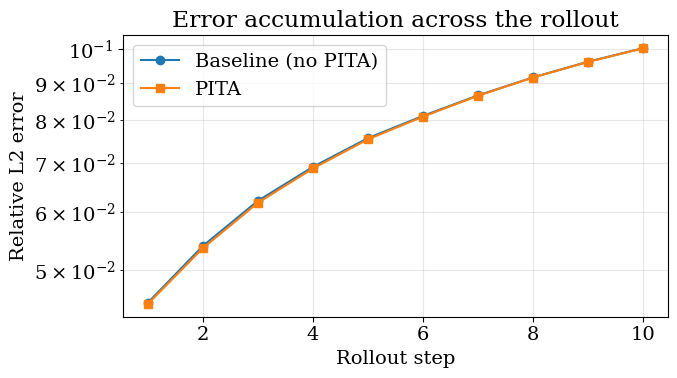

In [ ]:
# Relative L2 error at every horizon, averaged over the test set.
base_err = get_u_diff_norm(base_act, base_pred, num_steps=base_pred.shape[-1] - 1)
pita_err = get_u_diff_norm(pita_act, pita_pred, num_steps=pita_pred.shape[-1] - 1)

fig, ax = plt.subplots(figsize=(7, 4))
horizons = np.arange(1, len(base_err) + 1)
ax.plot(horizons, base_err, marker="o", label="Baseline (no PITA)")
ax.plot(horizons, pita_err, marker="s", label="PITA")
ax.set_yscale("log")
ax.set_xlabel("Rollout step")
ax.set_ylabel("Relative L2 error")
ax.set_title("Error accumulation across the rollout")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()


### Figure B — velocity-field snapshots at horizons [0, 3, 6, 9]

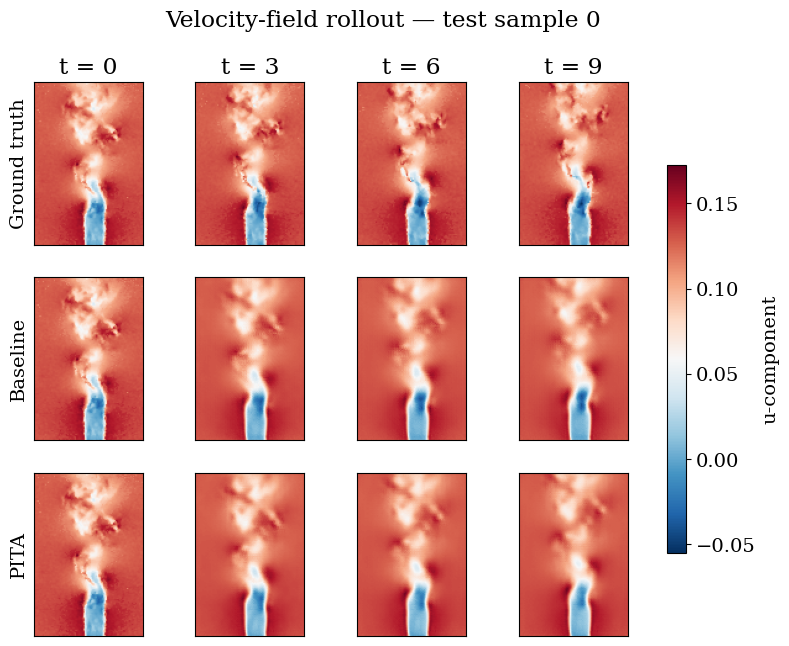

In [ ]:
# 3 rows (truth / baseline / PITA) × N timesteps. Use the u-component of one test sample.
sample_idx = 0
component  = 0          # 0 = u_x (horizontal), 1 = u_y (vertical)
horizons   = [0, 3, 6, 9]
rows = [
    ("Ground truth", base_act[component, sample_idx]),   # baseline & PITA share the same truth
    ("Baseline",     base_pred[component, sample_idx]),
    ("PITA",         pita_pred[component, sample_idx]),
]

gt_full = rows[0][1][..., horizons]
vmin, vmax = float(gt_full.min()), float(gt_full.max())

fig, axes = plt.subplots(len(rows), len(horizons), figsize=(2.5 * len(horizons), 2.4 * len(rows)))
for r, (label, field) in enumerate(rows):
    for c, t in enumerate(horizons):
        ax = axes[r, c]
        im = ax.imshow(field[..., t], origin="lower", cmap="RdBu_r", vmin=vmin, vmax=vmax)
        ax.set_xticks([]); ax.set_yticks([])
        if r == 0: ax.set_title(f"t = {t}")
        if c == 0: ax.set_ylabel(label)
fig.colorbar(im, ax=axes, shrink=0.7, label="u-component")
fig.suptitle(f"Velocity-field rollout — test sample {sample_idx}")
plt.show()


### Figure C — vorticity field at final horizon 

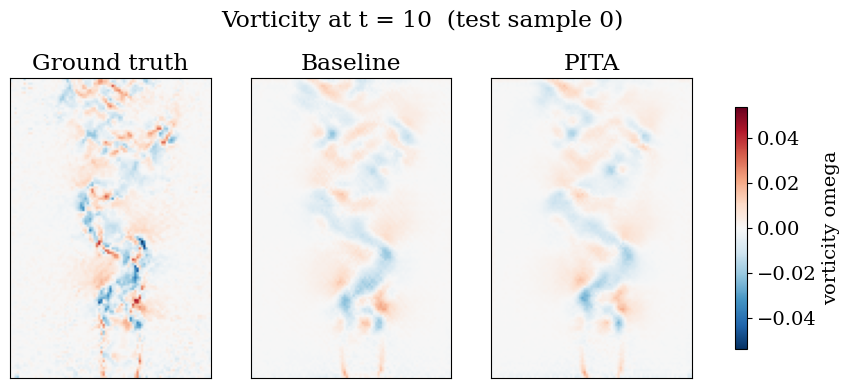

In [15]:
def vorticity(u, v):
    # central differences with edge replication; u, v shape [H, W]
    dv_dx = np.zeros_like(v); du_dy = np.zeros_like(u)
    dv_dx[:, 1:-1] = (v[:, 2:] - v[:, :-2]) / 2.0
    dv_dx[:, 0]    = v[:, 1] - v[:, 0]
    dv_dx[:, -1]   = v[:, -1] - v[:, -2]
    du_dy[1:-1, :] = (u[2:, :] - u[:-2, :]) / 2.0
    du_dy[0, :]    = u[1, :] - u[0, :]
    du_dy[-1, :]   = u[-1, :] - u[-2, :]
    return dv_dx - du_dy

sample_idx = 0
t_final    = base_act.shape[-1] - 1   # last available horizon

w_truth = vorticity(base_act[0, sample_idx, ..., t_final], base_act[1, sample_idx, ..., t_final])
w_base  = vorticity(base_pred[0, sample_idx, ..., t_final], base_pred[1, sample_idx, ..., t_final])
w_pita  = vorticity(pita_pred[0, sample_idx, ..., t_final], pita_pred[1, sample_idx, ..., t_final])

vmax = max(abs(w_truth).max(), abs(w_base).max(), abs(w_pita).max())
vmin = -vmax

fig, axes = plt.subplots(1, 3, figsize=(11, 4.5))
for ax, (title, field) in zip(
    axes,
    [("Ground truth", w_truth), ("Baseline", w_base), ("PITA", w_pita)],
):
    im = ax.imshow(field, origin="lower", cmap="RdBu_r", vmin=vmin, vmax=vmax)
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=axes, shrink=0.7, label="vorticity omega")
fig.suptitle(f"Vorticity at t = {t_final}  (test sample {sample_idx})")
plt.show()
